In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Results generated by our library
csv_our = pd.read_csv("results_our/results_our.csv")

# Results generated by the reference library
csv_ref = pd.read_csv("results_ref/results_ref.csv")

In [3]:
keys = ["dgp", "statistic", "method", "n", "B", "repetitions"]

# Merge the datasets so we can analyze the same cases together
comparison = csv_our.merge(
    csv_ref,
    on=keys,
    suffixes=("_our", "_ref"),
    validate="one_to_one",
)

# Confirm that the lengths of the data frames are consistent
assert len(comparison) == len(csv_ref) and len(comparison) == len(csv_our), (
    "Experiments don't match!"
)

comparison.head(5)

,method,nominal_1_sided_coverage_our,nominal_2_sided_coverage_our,lower_coverage_conditional_our,upper_coverage_conditional_our,two_sided_coverage_conditional_our,two_sided_coverage_our,mean_two_sided_length_conditional_our,median_two_sided_length_conditional_our,lower_bound_success_rate_our,...,nominal_2_sided_coverage_ref,lower_coverage_conditional_ref,upper_coverage_conditional_ref,two_sided_coverage_conditional_ref,two_sided_coverage_ref,mean_two_sided_length_conditional_ref,median_two_sided_length_conditional_ref,lower_bound_success_rate_ref,upper_bound_success_rate_ref,two_sided_success_rate_ref
0,percentile,0.975,0.95,0.941,0.939,0.880,0.880,1.243768,1.218740,1.0,...,0.95,0.944,0.936,0.880,0.880,1.242883,1.220705,1.0,1.0,1.0
1,double,0.975,0.95,0.967,0.964,0.931,0.931,1.686106,1.655035,1.0,...,0.95,0.967,0.964,0.931,0.931,1.692402,1.666504,1.0,1.0,1.0
2,percentile,0.975,0.95,0.964,0.964,0.928,0.928,0.677151,0.674429,1.0,...,0.95,0.963,0.966,0.929,0.929,0.678435,0.678903,1.0,1.0,1.0
3,double,0.975,0.95,0.972,0.974,0.946,0.946,0.724669,0.725210,1.0,...,0.95,0.974,0.973,0.947,0.947,0.723186,0.718664,1.0,1.0,1.0
4,percentile,0.975,0.95,0.970,0.972,0.942,0.942,0.345786,0.345058,1.0,...,0.95,0.969,0.971,0.940,0.940,0.345475,0.344736,1.0,1.0,1.0


In [4]:
bounds = ["lower_bound", "upper_bound", "two_sided"]

# None of the experiments lead to construction of invalid intervals for our library
for bound in bounds:
    assert comparison[f"{bound}_success_rate_our"].eq(1).all()

In [5]:
# Computation of Pearson correlation may cause division by 0 errors which lead
# to evaluation as NaN (since it isn't defined). This means that in some rare
# cases for small sample sizes, the method may not be able to construct a
# valid confidence interval. We can see that for bivariate normal with n = 8, the
# reference library failed to construct a valid CI for Pearson correlation
# in 3 / 1000 experiments.
success_cols = [f"{bound}_success_rate_ref" for bound in bounds]

failure_cases_ref = comparison.loc[
    comparison[success_cols].ne(1).any(axis=1),
    ["dgp", "method", "n", *success_cols],
]

failure_cases_ref

,dgp,method,n,lower_bound_success_rate_ref,upper_bound_success_rate_ref,two_sided_success_rate_ref
24,DGPBiNorm-1_1_2.0_0.5_1.0,percentile,8,0.997,0.997,0.997
25,DGPBiNorm-1_1_2.0_0.5_1.0,double,8,0.997,0.997,0.997


In [6]:
# Compute unconditional coverage from the conditional coverage.
# Instead of using (#covers / #successful_intervals), use (#covers / #all_repetitions)
# by multiplying the coverage by the success_rate, effectively treating
# unsuccessful constructions as non-coverage (in our case, this will have
# a very small effect on the reference library coverage for the bivariate normal
# case with n = 8). Invalid intetrvals are treated as failures to cover.
coverage_columns = ["lower_coverage", "upper_coverage", "two_sided_coverage"]
success_rate_columns = [
    "lower_bound_success_rate",
    "upper_bound_success_rate",
    "two_sided_success_rate",
]

for cov_col, rate_col in zip(coverage_columns, success_rate_columns):
    comparison[f"{cov_col}_our"] = (
        comparison[f"{cov_col}_conditional_our"] * comparison[f"{rate_col}_our"]
    )
    comparison[f"{cov_col}_ref"] = (
        comparison[f"{cov_col}_conditional_ref"] * comparison[f"{rate_col}_ref"]
    )

    comparison[f"{cov_col}_difference"] = (
        comparison[f"{cov_col}_our"] - comparison[f"{cov_col}_ref"]
    )

In [7]:
# This is not meant to be a formal hypothesis test but rather a quick diagnostic
# to see whether libraries produced very different coverage results
# Null hypothesis: coverage_our == coverage_ref
from scipy.stats import norm

coverage_specs = {
    "lower_coverage": 0.975,
    "upper_coverage": 0.975,
    "two_sided_coverage": 0.95,
}

comparison_checks = []

# This is aggregated by all interval bounds
for coverage, nominal in coverage_specs.items():
    our = comparison[f"{coverage}_our"]
    ref = comparison[f"{coverage}_ref"]
    repetitions = comparison["repetitions"]

    # Compute the difference between the coverage
    difference = our - ref

    pooled_coverage = (our + ref) / 2

    # SE estimate assuming independence and the null hypothesis. This is only
    # an approximation.
    difference_se = np.sqrt(
        pooled_coverage * (1 - pooled_coverage) * (2 / repetitions)
    )

    z_statistic = np.divide(
        difference,
        difference_se,
        out=np.zeros_like(difference),
        where=difference_se > 0,
    )

    # 2 sided p-value: probability that under the assumption of equal coverage
    # both methods produced a discrepancy as extreme or more
    p_value = 2 * norm.sf(z_statistic.abs())

    comparison_checks.append(
        comparison[
            ["dgp", "statistic", "method", "n", "B", "repetitions"]
        ].assign(
            coverage=coverage,
            nominal=nominal,
            coverage_our=our,
            coverage_ref=ref,
            difference=difference,
            difference_se=difference_se,
            p_value=p_value,
        )
    )

coverage_comparison = pd.concat(comparison_checks, ignore_index=True)
sorted_by_p_val = coverage_comparison.sort_values("p_value")

In [8]:
# Percentile method coverage discrepancy summary
percentile_df = comparison[comparison["method"] == "percentile"]

coverage_summary_percentile = pd.DataFrame(
    {
        column: {
            "mean_absolute_difference": percentile_df[f"{column}_difference"]
            .abs()
            .mean(),
            "maximum_absolute_difference": percentile_df[f"{column}_difference"]
            .abs()
            .max(),
        }
        for column in coverage_columns
    }
)
coverage_summary_percentile

,lower_coverage,upper_coverage,two_sided_coverage
mean_absolute_difference,0.002095,0.002429,0.003429
maximum_absolute_difference,0.008000,0.008000,0.010000


In [9]:
sorted_by_p_val[sorted_by_p_val["method"] == "percentile"].head(5)

,dgp,statistic,method,n,B,repetitions,coverage,nominal,coverage_our,coverage_ref,difference,difference_se,p_value
70,DGPBiNorm-1_1_2.0_0.5_1.0,corr,percentile,128,1000,1000,upper_coverage,0.975,0.971,0.963,0.008,0.007989,0.316637
92,DGPNorm_0_1,median,percentile,32,1000,1000,two_sided_coverage,0.950,0.950,0.941,0.009,0.010152,0.375326
112,DGPBiNorm-1_1_2.0_0.5_1.0,corr,percentile,128,1000,1000,two_sided_coverage,0.950,0.933,0.923,0.010,0.011560,0.387007
24,DGPBiNorm-1_1_2.0_0.5_1.0,corr,percentile,8,1000,1000,lower_coverage,0.975,0.934,0.926,0.008,0.011411,0.483236
8,DGPNorm_0_1,median,percentile,32,1000,1000,lower_coverage,0.975,0.974,0.969,0.005,0.007441,0.501641


In [10]:
# Double method coverage discrepancy summary
double_df = comparison[comparison["method"] == "double"]

coverage_summary_double = pd.DataFrame(
    {
        column: {
            "mean_absolute_difference": double_df[f"{column}_difference"]
            .abs()
            .mean(),
            "maximum_absolute_difference": double_df[f"{column}_difference"]
            .abs()
            .max(),
        }
        for column in coverage_columns
    }
)
coverage_summary_double

,lower_coverage,upper_coverage,two_sided_coverage
mean_absolute_difference,0.002429,0.002333,0.002238
maximum_absolute_difference,0.008000,0.008000,0.005000


In [11]:
sorted_by_p_val[sorted_by_p_val["method"] == "double"].head(5)

,dgp,statistic,method,n,B,repetitions,coverage,nominal,coverage_our,coverage_ref,difference,difference_se,p_value
67,DGPBiNorm-1_1_2.0_0.5_1.0,corr,double,8,1000,1000,upper_coverage,0.975,0.995,0.990,0.005,0.003858,0.195023
51,DGPNorm_0_1,median,double,32,1000,1000,upper_coverage,0.975,0.983,0.975,0.008,0.006412,0.212179
9,DGPNorm_0_1,median,double,32,1000,1000,lower_coverage,0.975,0.973,0.981,-0.008,0.006704,0.232737
109,DGPBiNorm-1_1_2.0_0.5_1.0,corr,double,8,1000,1000,two_sided_coverage,0.950,0.992,0.987,0.005,0.004558,0.272701
25,DGPBiNorm-1_1_2.0_0.5_1.0,corr,double,8,1000,1000,lower_coverage,0.975,0.997,0.994,0.003,0.002993,0.316219


The minimum $p$-values are approximately $0.32$ for percentile and $0.20$ for double.

Mean absolute coverage differences by interval type are approximately:
- Lower bound: $0.21 \%$ for the percentile and $0.24 \%$ for the double
- Upper bound: $0.24 \%$ for the percentile and $0.23 \%$ for the double
- Two sided: $0.34 \%$ for the percentile and $0.22 \%$ for the double

The maximum absolute difference in coverage is $1.0 \%$ for percentile and $0.8 \%$ for double.

Under the approximate independence-based diagnostic, none of the observed differences is unusually large relative to the expected MC variation. Overall the aggregate coverage results from the two libraries agree closely.

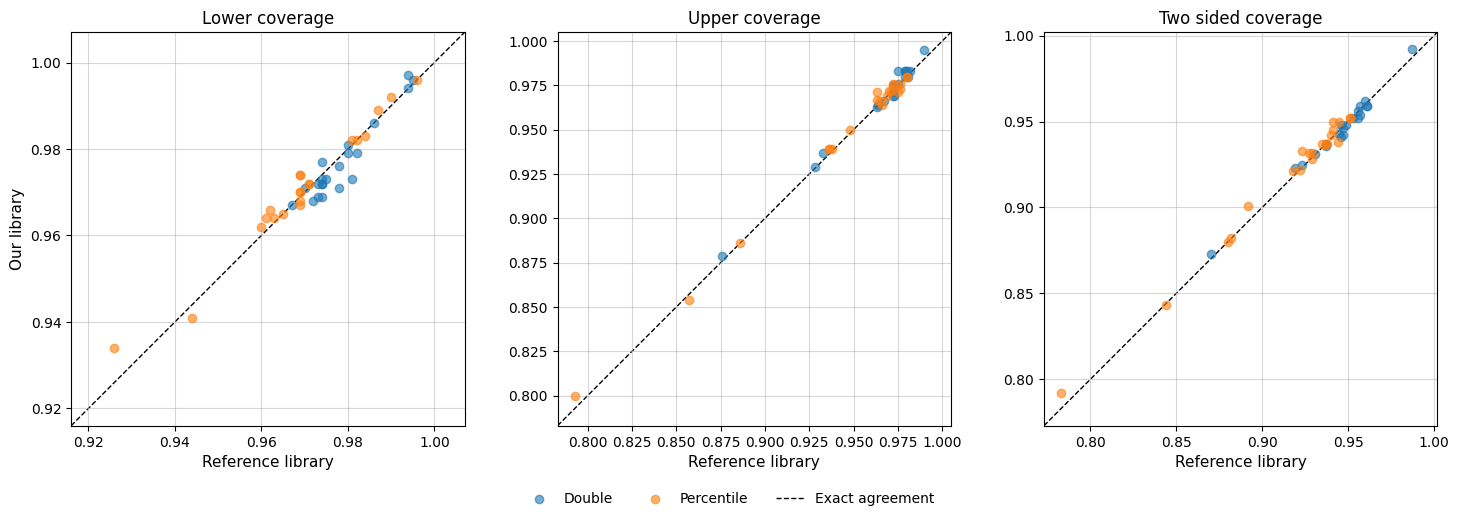

In [ ]:
plt.rcParams.update(
    {
        "font.size": 11,  # base size
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
    }
)

# Plot the coverage agreement of the libraries
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

for i, (coverage, nominal) in enumerate(coverage_specs.items()):
    x = comparison[f"{coverage}_ref"]
    y = comparison[f"{coverage}_our"]

    for method in ("double", "percentile"):
        our_coverage = comparison[(comparison["method"] == method)][
            f"{coverage}_our"
        ].to_numpy()
        ref_coverage = comparison[(comparison["method"] == method)][
            f"{coverage}_ref"
        ].to_numpy()

        ax[i].scatter(
            ref_coverage,
            our_coverage,
            alpha=0.6,
            label=method.capitalize(),
            zorder=2,
        )

    lower_limit = min(x.min(), y.min()) - 0.01
    upper_limit = max(x.max(), y.max()) + 0.01

    ax[i].set(
        xlim=(lower_limit, upper_limit),
        ylim=(lower_limit, upper_limit),
        xlabel="Reference library",
        aspect="equal",
    )

    if i == 0:
        ax[i].set_ylabel("Our library")

    ax[i].set_title(
        f"{coverage.replace('_', ' ').capitalize()}",
    )

    ax[i].plot(
        (lower_limit, upper_limit),
        (lower_limit, upper_limit),
        color="black",
        linestyle="--",
        linewidth=1,
        label="Exact agreement",
        zorder=1,
    )

    ax[i].grid(alpha=0.5)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
)

fig.tight_layout(rect=[0, 0.10, 1, 1])

In [13]:
# Analysis of two sided interval lengths (only for the successful cases)
comparison["relative_mean_length_difference_p"] = (
    (
        comparison["mean_two_sided_length_conditional_our"]
        - comparison["mean_two_sided_length_conditional_ref"]
    )
    / comparison["mean_two_sided_length_conditional_ref"]
    * 100
)

In [14]:
percentile_df = comparison[comparison["method"] == "percentile"]

rel_len_diff_summary_percentile = pd.DataFrame(
    {
        "two_sided": {
            "mean_absolute_relative_difference_p": percentile_df[
                "relative_mean_length_difference_p"
            ]
            .abs()
            .mean(),
            "maximum_absolute_relative_difference_p": percentile_df[
                "relative_mean_length_difference_p"
            ]
            .abs()
            .max(),
        }
    }
)
rel_len_diff_summary_percentile

,two_sided
mean_absolute_relative_difference_p,0.180968
maximum_absolute_relative_difference_p,0.792116


In [ ]:
# See the largest relative mean length difference percentage discrepancies
sorted_df = comparison[
    [
        "dgp",
        "statistic",
        "method",
        "n",
        "nominal_2_sided_coverage_our",
        "two_sided_coverage_our",
        "two_sided_coverage_ref",
        "mean_two_sided_length_conditional_our",
        "mean_two_sided_length_conditional_ref",
        "relative_mean_length_difference_p",
    ]
].sort_values(
    "relative_mean_length_difference_p",
    key=lambda x: x.abs(),
    ascending=False,
)

In [30]:
# Percentile method
sorted_df[sorted_df["method"] == "percentile"].head(10)

,dgp,statistic,method,n,nominal_2_sided_coverage_our,two_sided_coverage_our,two_sided_coverage_ref,mean_two_sided_length_conditional_our,mean_two_sided_length_conditional_ref,relative_mean_length_difference_p
36,DGPLogNorm_0_1,median,percentile,8,0.95,0.937,0.935,2.135883,2.119097,0.792116
6,DGPNorm_0_1,median,percentile,8,0.95,0.937,0.938,1.660627,1.652141,0.513637
18,DGPExp_1,median,percentile,8,0.95,0.932,0.927,1.357944,1.362615,-0.342789
14,DGPExp_1,mean,percentile,32,0.95,0.921,0.918,0.662403,0.660526,0.284070
20,DGPExp_1,median,percentile,32,0.95,0.938,0.944,0.692094,0.694059,-0.283138
40,DGPLogNorm_0_1,median,percentile,128,0.95,0.952,0.951,0.439520,0.438372,0.261884
10,DGPNorm_0_1,median,percentile,128,0.95,0.952,0.951,0.431223,0.430245,0.227301
2,DGPNorm_0_1,mean,percentile,32,0.95,0.928,0.929,0.677151,0.678435,-0.189276
8,DGPNorm_0_1,median,percentile,32,0.95,0.950,0.941,0.836147,0.837593,-0.172723
38,DGPLogNorm_0_1,median,percentile,32,0.95,0.950,0.945,0.887145,0.888369,-0.137777


In [15]:
double_df = comparison[comparison["method"] == "double"]

rel_len_diff_summary_double = pd.DataFrame(
    {
        "two_sided": {
            "mean_absolute_relative_difference_p": double_df[
                "relative_mean_length_difference_p"
            ]
            .abs()
            .mean(),
            "maximum_absolute_relative_difference_p": double_df[
                "relative_mean_length_difference_p"
            ]
            .abs()
            .max(),
        }
    }
)
rel_len_diff_summary_double

,two_sided
mean_absolute_relative_difference_p,0.552124
maximum_absolute_relative_difference_p,3.151277


In [31]:
# Double method
sorted_df[sorted_df["method"] == "double"].head(10)

,dgp,statistic,method,n,nominal_2_sided_coverage_our,two_sided_coverage_our,two_sided_coverage_ref,mean_two_sided_length_conditional_our,mean_two_sided_length_conditional_ref,relative_mean_length_difference_p
37,DGPLogNorm_0_1,median,double,8,0.95,0.959,0.961,2.709144,2.626379,3.151277
39,DGPLogNorm_0_1,median,double,32,0.95,0.954,0.957,0.929188,0.915649,1.478642
19,DGPExp_1,median,double,8,0.95,0.959,0.957,1.586392,1.563882,1.439328
21,DGPExp_1,median,double,32,0.95,0.948,0.949,0.723191,0.717530,0.788970
41,DGPLogNorm_0_1,median,double,128,0.95,0.952,0.953,0.444210,0.441507,0.612107
9,DGPNorm_0_1,median,double,32,0.95,0.956,0.956,0.867574,0.872341,-0.546500
13,DGPExp_1,mean,double,8,0.95,0.925,0.923,1.602764,1.610902,-0.505184
31,DGPLogNorm_0_1,mean,double,8,0.95,0.873,0.870,2.908439,2.894065,0.496668
23,DGPExp_1,median,double,128,0.95,0.943,0.945,0.351653,0.350034,0.462504
35,DGPLogNorm_0_1,mean,double,128,0.95,0.936,0.937,0.830497,0.833994,-0.419259


The mean percentage absolute relative length difference is approximately $0.18 \%$ for the percentile and $0.55 \%$ for the double method. The maximum absolute relative differences are approximatelly $0.79 \%$ and $3.15 \%$ respectively. The largest discrepancy occurs for the median of $\mathrm{Lognormal}(0, 1)$ with $n = 8$. Overall, both libraries produce closely agreeing mean interval lengths.